In [1]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
dataset = pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [4]:
dataset['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [5]:
dataset.columns

Index(['User ID', 'Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [6]:
independent = dataset[['Age', 'EstimatedSalary', 'Gender_Male']]
independent

,Age,EstimatedSalary,Gender_Male
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1
...,...,...,...
395,46,41000,0
396,51,23000,1
397,50,20000,0
398,36,33000,1


In [7]:
dependent = dataset[['Purchased']]
dependent

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [8]:
# Splitting data into training and testing sets
X_train,X_test,Y_train,Y_test = train_test_split(independent,dependent,test_size=0.25,random_state=0)

In [9]:
X_train.shape

(300, 3)

In [10]:
X_test.shape

(100, 3)

In [11]:
Y_train.shape

(300, 1)

In [12]:
Y_test.shape

(100, 1)

In [13]:
# Model_training
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy',splitter='best',max_features='log2',random_state=0)
classifier.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', max_features='log2', random_state=0)

<function matplotlib.pyplot.show(close=None, block=None)>

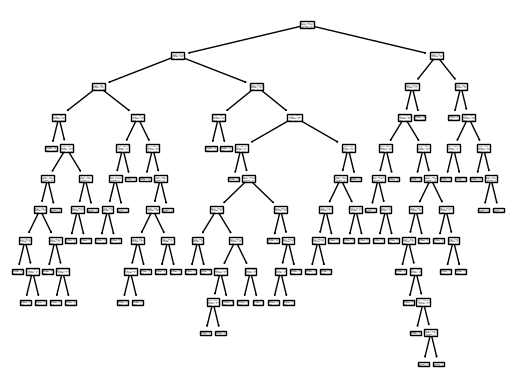

In [14]:
from sklearn import tree
tree.plot_tree(classifier)
plt.show

In [15]:
# Model prediction
Y_pred = classifier.predict(X_test)
Y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1])

In [16]:
# Model evaluation
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
cm

array([[65,  3],
       [ 4, 28]])

In [17]:
from sklearn.metrics import classification_report
class_report = classification_report(Y_test,Y_pred)

In [18]:
print(class_report)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        68
           1       0.90      0.88      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



In [19]:
age_input=float(input("Enter your Age:"))
salary_input=float(input("Enter your Salary:"))
sex_male_input=int(input("Sex Male=1 female=0"))

In [20]:
result = classifier.predict([[age_input,salary_input,sex_male_input]])
result

C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])